<a href="https://colab.research.google.com/github/johanordonez/CIENCIA-DE-DATOS---MAIE-2026A/blob/main/10_icd_taller6_regresion_lineal_JOHAN_ORDO%C3%91EZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ESTUDIANTE:** JOHAN DAVID ORDOÑEZ CASTRO - **CODIGO:** 224393001


# **¡¡ ANTES DE EMPEZAR !!**

Deshabilita autocompletar con IA. Esta acción te ayudará a aprender de verdad. Si estás en Colab sigue estos pasos:

1.   Ir a Herramientas \ Configuración \ Asistencia de IA
2.   Desactivar la casilla **"Mostrar autocompletado impulsado por IA"**
3.   Activar la casilla **"Ocultar funciones de IA generativa"**


# **REGRESIÓN LINEAL MÚLTIPLE**

En los módulos anteriores aprendimos a manipular datos. Ahora empezaremos a crear modelos. La **Regresión Lineal Múltiple** es una técnica estadística que nos permite predecir el valor de una variable (variable dependiente $y$) basándonos en múltiples variables predictoras (variables independientes $x_1, x_2, ..., x_n$).

El modelo matemático asume una relación lineal, representada así:
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$$

Donde:
* $\beta_0$ es el intercepto (el valor esperado de $y$ cuando todas las $x$ son cero).
* $\beta_i$ son los coeficientes (indican cuánto cambia $y$ por cada unidad que aumenta la variable $x_i$).
* $\epsilon$ es el error del modelo.


### Montar Google Drive

Para acceder a archivos almacenados en tu Google Drive directamente desde este cuaderno de Colab, puedes ejecutar el siguiente código. Esto te pedirá que autorices a Colab a acceder a tus archivos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1.1. Caso Práctico (Eficiencia Energética)**

Queremos predecir el **Consumo Eléctrico (kWh)** de una planta basándonos en tres sensores: la **Temperatura (°C)** exterior, la **Humedad (%)**, y el **Número de Máquinas** operando simultáneamente. Primero, creemos nuestros datos para el ejemplo (**Nota:** en un problema real, estos datos no se crean, sino que se obtienen a partir de mediciones de los sensores):

In [ ]:
# --- LIBRERÍAS Y DATOS ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generamos datos sintéticos simulando 100 horas de operación
np.random.seed(42)
n_datos = 100

# Variables predictoras (X)
temperatura = np.random.uniform(15, 35, n_datos)
humedad = np.random.uniform(30, 80, n_datos)
maquinas = np.random.randint(5, 20, n_datos)

# Variable objetivo (Y): Simulamos una relación real añadiendo "ruido" de los sensores
ruido = np.random.normal(0, 5, n_datos)
consumo = 50 + (2.5 * temperatura) + (0.5 * humedad) + (15 * maquinas) + ruido

# Consolidamos en un DataFrame
df_planta = pd.DataFrame({
    'Temperatura_C': temperatura,
    'Humedad_Rel': humedad,
    'Maquinas_Activas': maquinas,
    'Consumo_kWh': consumo
})

print("--- MUESTRA DE LECTURAS DE LA PLANTA ---")
display(df_planta.head())


--- MUESTRA DE LECTURAS DE LA PLANTA ---


,Temperatura_C,Humedad_Rel,Maquinas_Activas,Consumo_kWh
0,22.490802,31.571459,12,305.163110
1,34.014286,61.820521,8,294.760663
2,29.639879,45.717799,15,373.113365
3,26.973170,55.428535,5,216.102507
4,18.120373,75.378324,12,318.277211


**1.2 Ajuste del Modelo con `statsmodels`**

En Python existen dos librerías principales para hacer **Regresiones Lineales Multivariables**: `statsmodels` y `scikit-learn`. Mientras `statsmodels` es la mejor opción cuando nos interesa analizar las estadísticas (p-valores, intervalos de confianza), `scikit-learn` está optimizada para hacer predicciones de *Machine Learning*.

Usemos `statsmodels`:

In [ ]:
# --- MODELO MLR USANDO statsmodels ---

import statsmodels.api as sm

# 1. Definir variables predictoras (X) y variable respuesta (y)
X = df_planta[['Temperatura_C', 'Humedad_Rel', 'Maquinas_Activas']]
y = df_planta['Consumo_kWh']

# 2. statsmodels exige añadir explícitamente una constante para calcular beta_0 (el intercepto)
X_con_constante = sm.add_constant(X)
print("--- MUESTRA EL DataFrame AUMENTADO CON LA CONSTANTE ---")
display(X_con_constante)

# 3. Ajustamos el modelo usando Mínimos Cuadrados Ordinarios (OLS)
modelo_sm = sm.OLS(y, X_con_constante).fit()

# 4. Mostramos el resumen estadístico
print(modelo_sm.summary())


--- MUESTRA EL DataFrame AUMENTADO CON LA CONSTANTE ---


,const,Temperatura_C,Humedad_Rel,Maquinas_Activas
0,1.0,22.490802,31.571459,12
1,1.0,34.014286,61.820521,8
2,1.0,29.639879,45.717799,15
3,1.0,26.973170,55.428535,5
4,1.0,18.120373,75.378324,12
...,...,...,...,...
95,1.0,24.875912,47.460479,6
96,1.0,25.454657,66.297784,13
97,1.0,23.550820,74.855513,14
98,1.0,15.508383,74.354321,19


                            OLS Regression Results                            
Dep. Variable:            Consumo_kWh   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     6545.
Date:                Sat, 16 May 2026   Prob (F-statistic):          7.52e-111
Time:                        05:22:22   Log-Likelihood:                -299.20
No. Observations:                 100   AIC:                             606.4
Df Residuals:                      96   BIC:                             616.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               46.8322      3.251  

**1.3. Lectura del Reporte**

Debemos concentrarnos en tres indicadores:
1.  **R-squared ($R^2$):** Indica la bondad de ajuste. Es decir, el porcentaje del Consumo que explicamos con nuestro modelo. Si está cerca de 1.0, el ajuste es bueno.
2.  **coef:** Son los pesos $\beta$. Nos dicen, por ejemplo, cuántos kWh extra se consumen por cada máquina adicional encendida.
3.  **P>|t| (p-valor):** Si es menor a 0.05, la variable es estadísticamente significativa y aporta información útil al modelo.


**1.4. Validación de Supuestos**

Para poder confiar en el modelo obtenido, los errores (también llamados residuos) deben cumplir ciertas características. Por ejemplo, seguir una **distribución normal**, o cumplir con la **homocedasticidad** (la varianza de los errores debe mantenerse constante).

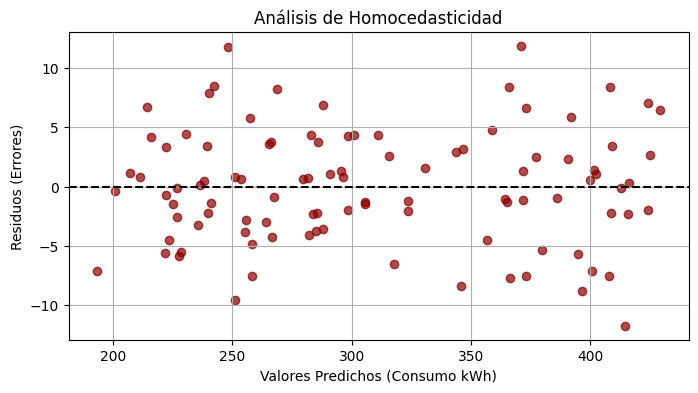

In [ ]:
# --- EVALUACIÓN DE RESIDUOS ---

# Calculamos las predicciones del modelo
predicciones = modelo_sm.predict(X_con_constante)
# El residuo es la diferencia entre el valor real y el valor predicho
residuos = y - predicciones

# Gráfica de Residuos vs Predicciones
plt.figure(figsize=(8, 4))
plt.scatter(predicciones, residuos, alpha=0.7, color="darkred")
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análisis de Homocedasticidad')
plt.xlabel('Valores Predichos (Consumo kWh)')
plt.ylabel('Residuos (Errores)')
plt.grid(True)
plt.show()

# Si los puntos están dispersos sin un patrón claro formando una banda horizontal, hay homocedasticidad.


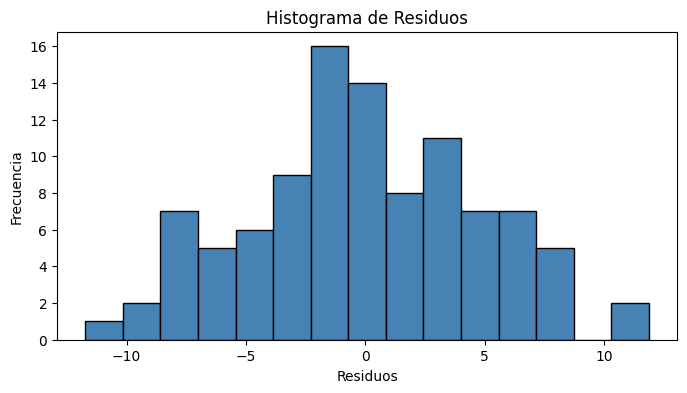

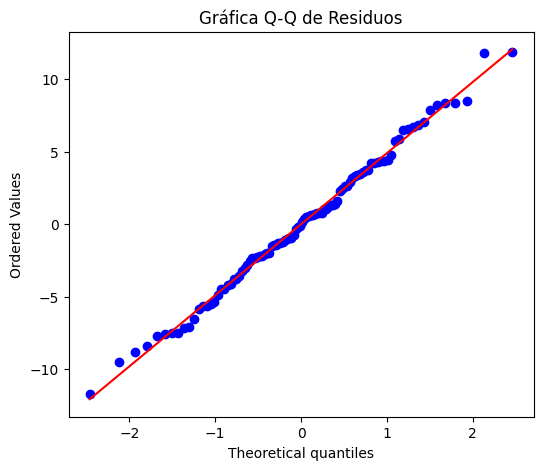

Prueba de Shapiro-Wilk: estadístico = 0.9934, p-valor = 0.9089
Conclusión: p-valor > 0.05 → Los residuos siguen una distribución normal ✓


In [ ]:
# ---  PROPONER AQUÍ UN CÓDIGO PARA EVALUAR SI LOS ERRORES SE DISTRIBUYEN DE FORMA NORMAL"
# --- EVALUACIÓN DE NORMALIDAD DE LOS RESIDUOS ---

from scipy import stats

# Gráfica 1: Histograma de los residuos
plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=15, color='steelblue', edgecolor='black')
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(False)
plt.show()

# Gráfica 2: Q-Q Plot (si los puntos siguen la línea roja, hay normalidad)
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(residuos, dist="norm", plot=ax)
ax.set_title('Gráfica Q-Q de Residuos')
plt.grid(False)
plt.show()

# Prueba estadística: Shapiro-Wilk
# H0: los residuos siguen una distribución normal
# Si p-valor > 0.05, no rechazamos H0 → hay normalidad
stat, p_valor = stats.shapiro(residuos)
print(f"Prueba de Shapiro-Wilk: estadístico = {stat:.4f}, p-valor = {p_valor:.4f}")

if p_valor > 0.05:
    print("Conclusión: p-valor > 0.05 → Los residuos siguen una distribución normal ✓")
else:
    print("Conclusión: p-valor ≤ 0.05 → Los residuos NO siguen una distribución normal ✗")

**1.5. Ajuste y Predicción con `scikit-learn`**

En un entorno de producción de Ciencia de Datos, preferimos `scikit-learn` por su facilidad para hacer predicciones rápidas e integrarse en flujos de trabajo que involucran *Machine Learning*.

In [ ]:
# --- MODELO MLR USANDO scikit-learn ---

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Instanciamos el modelo
modelo_ml = LinearRegression()

# 2. Entrenamos (Ajustamos) el modelo. Nota: aquí no necesitamos agregar constante manualmente
modelo_ml.fit(X, y)

print("Intercepto (Beta_0):", modelo_ml.intercept_)
print("Coeficientes (Betas):", modelo_ml.coef_)

# 3. Calculamos las métricas de error y precisión
predicciones = modelo_ml.predict(X)
mse = mean_squared_error(y, predicciones)
r2 = r2_score(y, predicciones)

print(f"\nError Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")

# 4. Hacemos una predicción futura:
# Mañana tendremos 30°C, 65% de humedad y 14 máquinas activas. ¿Cuál será el consumo?
datos_manana = pd.DataFrame({'Temperatura_C': [30], 'Humedad_Rel': [65], 'Maquinas_Activas': [14]})
consumo_estimado = modelo_ml.predict(datos_manana)

print(f"\nConsumo estimado para mañana: {consumo_estimado[0]:.2f} kWh")


Intercepto (Beta_0): 46.83218971790984
Coeficientes (Betas): [ 2.50900137  0.58956939 14.91070275]

Error Cuadrático Medio (MSE): 23.25
Coeficiente de Determinación (R^2): 0.9951

Consumo estimado para mañana: 369.17 kWh


# Reto (Optimización de Invernaderos Inteligentes):

Se está desarrollando un sistema de control distribuido para un conjunto de micro-invernaderos. Se tiene una base de datos histórica con el **Rendimiento (kg/m2)** de un cultivo específico, en función de tres variables controladas:

1.  **Luz_Solar** (horas diarias de exposición)
2.  **Fertilizante** (gramos aplicados por $m^2$)
3.  **Caudal_Riego** (litros por $m^2$)

Su tarea es implementar un código que cumpla con los siguientes puntos:

* Entrene un modelo de regresión lineal con los datos proporcionados.
* Imprima en pantalla la bondad del ajuste ($R^2$) **¿El modelo es confiable?**
* Realice un análisis de validación de los supuestos: error con distribución normal y homocedasticidad.
* Imprima en pantalla los coeficientes del modelo para entender qué variable tiene más peso en el crecimiento del cultivo. **Explique los resultados**.
* El sistema de control automatizado planea configurar el entorno a **8 horas de luz, 50 gramos de fertilizante y 15 litros de riego**. Utilice su modelo entrenado para estimar e imprimir cuál será el rendimiento bajo esas condiciones.

--- PRIMEROS 5 REGISTROS DE LA BASE DE DATOS ---


,Luz_Solar,Fertilizante,Caudal_Riego,Rendimiento_kg_m2
0,8.5,50,15,4.2
1,7.0,40,12,3.1
2,9.2,60,18,5.4
3,5.5,30,8,1.6
4,10.1,65,20,6.1



--- BONDAD DE AJUSTE ---
R² = 0.9990
El modelo es confiable: explica más del 80% de la variabilidad del Rendimiento.


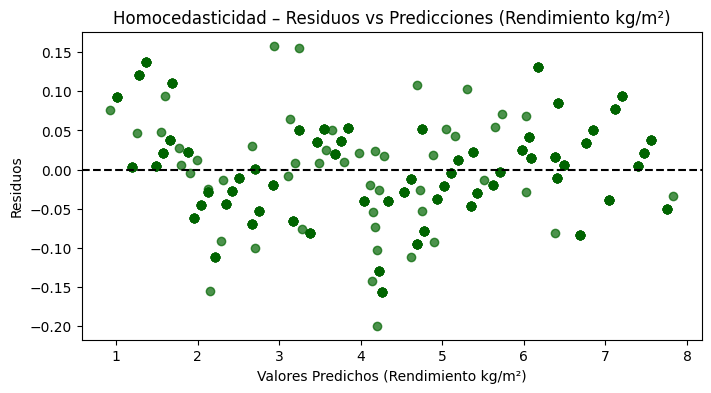

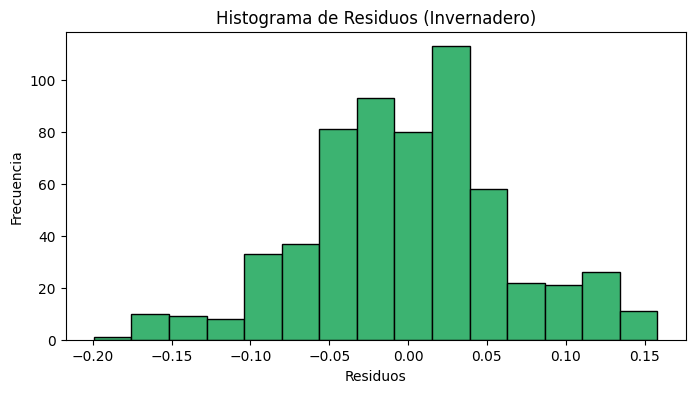

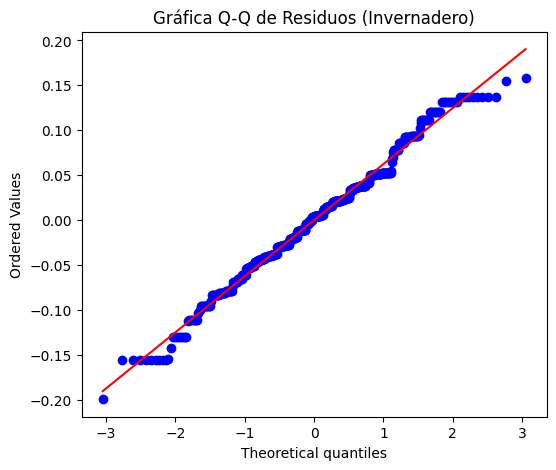


Prueba Shapiro-Wilk: estadístico = 0.9910, p-valor = 0.0010
Normalidad: Los residuos NO siguen una distribución normal ✗

--- COEFICIENTES DEL MODELO ---
Intercepto (β₀):         -2.4605
Coeficiente Luz_Solar      : 0.2660
Coeficiente Fertilizante   : 0.0568
Coeficiente Caudal_Riego   : 0.1056

La variable con mayor influencia en el Rendimiento es: 'Luz_Solar'
Interpretación: el coeficiente indica cuántos kg/m² cambia el Rendimiento
por cada unidad adicional de esa variable, manteniendo las demás constantes.

--- PREDICCIÓN DEL SISTEMA DE CONTROL ---
Configuración: 8h de luz, 50g fertilizante, 15L riego
Rendimiento estimado: 4.09 kg/m²


In [ ]:
# --- DATOS DE ENTRADA (NO MODIFICAR) ---
sheet_id_reto = "1tioKUNb6o02g37nii5qHLba4CmV9G9Wsjvqtleepid0"
url_reto = f"https://docs.google.com/spreadsheets/d/{sheet_id_reto}/export?format=csv"

df_invernadero = pd.read_csv(url_reto)

print("--- PRIMEROS 5 REGISTROS DE LA BASE DE DATOS ---")
display(df_invernadero.head())


# --- TU CÓDIGO EMPIEZA AQUÍ ---

# ── 1. DEFINIR VARIABLES ────────────────────────────────────────────────────
X_inv = df_invernadero[['Luz_Solar', 'Fertilizante', 'Caudal_Riego']]
y_inv = df_invernadero['Rendimiento_kg_m2']

# ── 2. ENTRENAR EL MODELO ───────────────────────────────────────────────────
modelo_inv = LinearRegression()
modelo_inv.fit(X_inv, y_inv)

# ── 3. BONDAD DE AJUSTE ─────────────────────────────────────────────────────
predicciones_inv = modelo_inv.predict(X_inv)
r2_inv = r2_score(y_inv, predicciones_inv)

print(f"\n--- BONDAD DE AJUSTE ---")
print(f"R² = {r2_inv:.4f}")

if r2_inv >= 0.8:
    print("El modelo es confiable: explica más del 80% de la variabilidad del Rendimiento.")
elif r2_inv >= 0.5:
    print("El modelo tiene un ajuste moderado. Podría mejorarse con más variables.")
else:
    print("El modelo tiene un ajuste bajo. La relación lineal no es suficiente.")

# ── 4. VALIDACIÓN DE SUPUESTOS ──────────────────────────────────────────────
residuos_inv = y_inv - predicciones_inv

# 4a. Homocedasticidad: Residuos vs Valores Predichos
plt.figure(figsize=(8, 4))
plt.scatter(predicciones_inv, residuos_inv, alpha=0.7, color='darkgreen')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Homocedasticidad – Residuos vs Predicciones (Rendimiento kg/m²)')
plt.xlabel('Valores Predichos (Rendimiento kg/m²)')
plt.ylabel('Residuos')
plt.grid(False)
plt.show()
# Si los puntos forman una banda horizontal sin patrón → hay homocedasticidad

# 4b. Normalidad: Histograma + Q-Q Plot + Shapiro-Wilk
plt.figure(figsize=(8, 4))
plt.hist(residuos_inv, bins=15, color='mediumseagreen', edgecolor='black')
plt.title('Histograma de Residuos (Invernadero)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(residuos_inv, dist="norm", plot=ax)
ax.set_title('Gráfica Q-Q de Residuos (Invernadero)')
plt.grid(False)
plt.show()

stat_inv, p_inv = stats.shapiro(residuos_inv)
print(f"\nPrueba Shapiro-Wilk: estadístico = {stat_inv:.4f}, p-valor = {p_inv:.4f}")
if p_inv > 0.05:
    print("Normalidad: Los residuos siguen una distribución normal ✓")
else:
    print("Normalidad: Los residuos NO siguen una distribución normal ✗")

# ── 5. COEFICIENTES E INTERPRETACIÓN ────────────────────────────────────────
print(f"\n--- COEFICIENTES DEL MODELO ---")
print(f"Intercepto (β₀):         {modelo_inv.intercept_:.4f}")

nombres = ['Luz_Solar', 'Fertilizante', 'Caudal_Riego']
for nombre, coef in zip(nombres, modelo_inv.coef_):
    print(f"Coeficiente {nombre:15s}: {coef:.4f}")

# Identificar la variable con mayor peso (en valor absoluto)
idx_mayor = np.argmax(np.abs(modelo_inv.coef_))
print(f"\nLa variable con mayor influencia en el Rendimiento es: '{nombres[idx_mayor]}'")
print("Interpretación: el coeficiente indica cuántos kg/m² cambia el Rendimiento")
print("por cada unidad adicional de esa variable, manteniendo las demás constantes.")

# ── 6. PREDICCIÓN PARA EL SISTEMA DE CONTROL ────────────────────────────────
condiciones_control = pd.DataFrame({
    'Luz_Solar':     [8],
    'Fertilizante':  [50],
    'Caudal_Riego':  [15]
})

rendimiento_estimado = modelo_inv.predict(condiciones_control)
print(f"\n--- PREDICCIÓN DEL SISTEMA DE CONTROL ---")
print(f"Configuración: 8h de luz, 50g fertilizante, 15L riego")
print(f"Rendimiento estimado: {rendimiento_estimado[0]:.2f} kg/m²")